# IABR-v2 dataset: what one sample is, and how it is generated (start to finish)

This notebook is **self-contained** (numpy + matplotlib only, runs in about 20 s, no GPU, no data files). It re-implements the
generator used for IABR-Net v2 training and evaluation, step by step, and shows every intermediate object for **one scene**,
then zooms out to the whole training stream and the frozen evaluation banks.

| Section | What you see |
|---|---|
| 0 | The generator code (compact, same formulas as `iabr2_sim.py` and the authors' `dldoa_dataset_generation.py`) |
| 1 | The complete flow in one picture |
| 2 - 9 | One scene, step by step: angles, gains, channel, codebooks, clean `Y`, impairment, noise, ground truth |
| 10 | Same scene under different SNR and impairment levels (no impairment vs impairment) |
| 11 | Exactly what one training sample looks like as tensors |
| 12 | The training stream as a whole: distributions of L, SNR, impairment, angles |
| 13 | The frozen evaluation banks |
| 14 | Self-checks (assertions) and an optional bit-exact comparison with the project code |
| 15 | Caveats found by the forensic audit |

**Important:** there is **no stored training dataset**. Training draws fresh random scenes forever (48,000 steps x 256 = 12,288,000 scenes,
each seen once). Only the *evaluation banks* are frozen files.

## 0. The generator (all formulas in one place)

In [1]:
import math, os, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, FancyArrowPatch
warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold"})
np.set_printoptions(precision=3, suppress=True, linewidth=140)

# ---- configuration: the values actually used by the IABR-v2 notebook (CFG) ----
CFG = dict(N=16, grid=32, heat_sigma=1.0, sep=math.pi / 6,
           train_L=(1, 9), train_snr=(-15, 24), train_phase_max=8.0, train_gain_max=3.0, clean_frac=0.2,
           steps=48000, batch=256)
N = CFG["N"]; P = Q = NT = NR = N

# ---- 1. angles: rejection sampler of the authors' code (dldoa_dataset_generation.generate_points) ----
def generate_points(M, delta, rng, max_attempts=10000):
    pts = []
    for _ in range(max_attempts):
        if len(pts) == M: break
        x = rng.uniform(0, math.pi); y = rng.uniform(0, math.pi)           # x = AoD phi, y = AoA psi
        if not any(math.hypot(x - p[0], y - p[1]) < delta for p in pts):
            pts.append((x, y))
    if len(pts) < M: raise ValueError("could not place points")
    return pts

def sample_paths(L_arr, rng, sep=CFG["sep"], lmax=None):
    # returns psi (AoA), phi (AoD), alpha (complex gains), padded with NaN / 0 up to lmax paths
    B = len(L_arr); lmax = lmax or int(max(L_arr))
    psi = np.full((B, lmax), np.nan); phi = np.full((B, lmax), np.nan); alpha = np.zeros((B, lmax), complex)
    for b, L in enumerate(L_arr):
        L = int(L)
        pts = generate_points(L, sep, rng)
        a = np.sqrt(1 / L) * (rng.standard_normal(L) + 1j * rng.standard_normal(L)) / np.sqrt(2)   # alpha ~ CN(0, 1/L)
        a = a[np.argsort(-np.abs(a))]                                                               # strongest first
        phi[b, :L] = [p[0] for p in pts]; psi[b, :L] = [p[1] for p in pts]; alpha[b, :L] = a
    return psi, phi, alpha

# ---- 2. steering vectors and DFT codebooks (half-wavelength ULA, N = 16) ----
def steering(n, ang):
    return np.exp(-1j * np.pi * np.cos(ang)[..., None] * np.arange(n)) / np.sqrt(n)

def dft_codebook(n, sign):
    idx = np.arange(n); cosv = (1 / np.pi) * np.angle(np.exp(sign * 1j * 2 * np.pi / n * idx))   # beam centres in cos-angle
    return np.exp(-1j * np.pi * np.arange(n)[:, None] * cosv[None, :]) / np.sqrt(n)
F_IDEAL = dft_codebook(P, +1)      # Tx codebook (NT x P)
W_IDEAL = dft_codebook(Q, -1)      # Rx codebook (NR x Q)

# ---- 3. channel + impairment + noise :  Y = W^H H F + Z ----
def simulate(psi, phi, alpha, snr_db, rng, phase_deg_max=0.0, gain_db_max=0.0, unit_imp=None, unit_noise=None):
    B, Lm = alpha.shape
    ps, ph = np.nan_to_num(psi), np.nan_to_num(phi)
    a_r = steering(NR, ps); a_t = steering(NT, ph)                                        # (B,Lm,N)
    H = np.sqrt(NT * NR) * np.einsum("bl,bln,blm->bnm", alpha, a_r, np.conj(a_t))          # antenna-domain channel
    pdm = np.broadcast_to(np.asarray(phase_deg_max, float), (B,)); gdm = np.broadcast_to(np.asarray(gain_db_max, float), (B,))
    if unit_imp is None:                                                                   # draw order = original code
        unit_imp = [rng.uniform(-1, 1, (B, NR)), rng.uniform(-1, 1, (B, NT)), rng.uniform(-1, 1, (B, NR)), rng.uniform(-1, 1, (B, NT))]
    u_er, u_et, u_gr, u_gt = unit_imp
    eps_r = u_er * np.deg2rad(pdm)[:, None]; eps_t = u_et * np.deg2rad(pdm)[:, None]      # phase error, uniform +-delta
    g_r = 10 ** (u_gr * gdm[:, None] / 20);  g_t = 10 ** (u_gt * gdm[:, None] / 20)        # gain error, uniform in dB
    D_r = g_r * np.exp(1j * eps_r); D_t = g_t * np.exp(1j * eps_t)                          # per-antenna complex error
    W = D_r[:, :, None] * W_IDEAL[None]; F = D_t[:, :, None] * F_IDEAL[None]                # impaired codebooks
    Y_imp = np.einsum("bnq,bnm,bmp->bqp", np.conj(W), H, F)                                 # noiseless, impaired
    Y_ideal = np.einsum("nq,bnm,mp->bqp", np.conj(W_IDEAL), H, F_IDEAL)                     # noiseless, ideal hardware
    if unit_noise is None:
        unit_noise = rng.standard_normal((B, Q, P)) + 1j * rng.standard_normal((B, Q, P))
    s = np.sqrt(10 ** (-np.broadcast_to(np.asarray(snr_db, float), (B,)) / 10) / 2)[:, None, None]
    Z = s * unit_noise                                                                      # CN(0, 10^(-SNR/10)) per entry
    return dict(Y=Y_imp + Z, Y_imp=Y_imp, Y_ideal=Y_ideal, Z=Z, H=H, D_r=D_r, D_t=D_t, W=W, F=F,
                unit_imp=unit_imp, unit_noise=unit_noise)

# ---- 4. labels ----
def angles_to_cells(psi, phi, n=16):
    # continuous beam-grid coordinates: row (AoA) = n*wrap(-pi cos psi)/2pi , col (AoD) = n*wrap(pi cos phi)/2pi
    w = lambda x: np.mod(x, 2 * np.pi)
    return n * w(-np.pi * np.cos(psi)) / (2 * np.pi), n * w(np.pi * np.cos(phi)) / (2 * np.pi)

def heat_targets(psi, phi, G=32, sigma=1.0):
    B, Lm = psi.shape
    q, p = angles_to_cells(np.nan_to_num(psi), np.nan_to_num(phi), G)
    qi = np.round(q).astype(int) % G; pi_ = np.round(p).astype(int) % G
    g = np.arange(G, dtype=np.float32)
    dq = np.abs(g[None, None, :] - qi[..., None]); dq = np.minimum(dq, G - dq)               # circular distance (wrap-around)
    dp = np.abs(g[None, None, :] - pi_[..., None]); dp = np.minimum(dp, G - dp)
    eq = np.exp(-dq ** 2 / (2 * sigma ** 2)) * (~np.isnan(psi))[..., None]; ep = np.exp(-dp ** 2 / (2 * sigma ** 2))
    h = np.zeros((B, G, G), np.float32)
    for l in range(Lm): np.maximum(h, eq[:, l, :, None] * ep[:, l, None, :], out=h)          # max over paths
    return h

def project_impairment(x):
    n = np.arange(16) - 7.5                                    # remove mean and linear ramp (not identifiable)
    x = x - x.mean(-1, keepdims=True)
    return x - (x @ n)[..., None] / (n @ n) * n

def impairment_targets(D_r, D_t):
    # antenna-domain distortion H~ = conj(D_r) H D_t : Rx phase = -eps_r, Tx phase = +eps_t ; log-gain = ln g
    ph = np.concatenate([project_impairment(-np.angle(D_r)), project_impairment(np.angle(D_t))], 1)
    lg = np.concatenate([np.log(np.abs(D_r)), np.log(np.abs(D_t))], 1)
    lg = np.concatenate([lg[:, :16] - lg[:, :16].mean(1, keepdims=True), lg[:, 16:] - lg[:, 16:].mean(1, keepdims=True)], 1)
    return np.stack([ph, lg], -1).astype(np.float32)

def make_batch(rng, B, cfg=CFG):
    # one training batch, exactly the recipe of iabr2_sim.make_batch
    L = rng.integers(cfg["train_L"][0], cfg["train_L"][1] + 1, B)
    snr = rng.integers(cfg["train_snr"][0], cfg["train_snr"][1] + 1, B).astype(float)
    clean = rng.uniform(size=B) < cfg["clean_frac"]
    pd = np.where(clean, 0.0, rng.uniform(0, cfg["train_phase_max"], B))
    gd = np.where(clean, 0.0, rng.uniform(0, cfg["train_gain_max"], B))
    psi, phi, alpha = sample_paths(L, rng, lmax=cfg["train_L"][1])
    sim = simulate(psi, phi, alpha, snr, rng, phase_deg_max=pd, gain_db_max=gd)
    y = np.stack([sim["Y"].real, sim["Y"].imag], 1).astype(np.float32)
    return dict(y=y, heat=heat_targets(psi, phi, cfg["grid"], cfg["heat_sigma"]), imp=impairment_targets(sim["D_r"], sim["D_t"]),
                L=L, snr=snr, clean=clean, pd=pd, gd=gd, psi=psi, phi=phi, alpha=alpha)

def mark(ax, q, p, n=16, color="white", ms=7, mew=1.8):
    q = np.asarray(q, float); p = np.asarray(p, float)
    for dq in (-n, 0, n):
        for dp in (-n, 0, n):
            ax.plot(p + dp, q + dq, "x", color=color, ms=ms, mew=mew)
    ax.set_xlim(-.5, n - .5); ax.set_ylim(n - .5, -.5)

def show_Y(ax, Y, title, q=None, p=None, cmap="viridis", vmax=None, n=16):
    im = ax.imshow(np.abs(Y), cmap=cmap, extent=(-.5, n - .5, n - .5, -.5), vmax=vmax)
    if q is not None: mark(ax, q, p, n)
    ax.set_title(title); ax.set_xlabel("Tx beam p (AoD)"); ax.set_ylabel("Rx beam q (AoA)")
    return im

print("generator ready | array N =", N, "| codebooks", F_IDEAL.shape, W_IDEAL.shape)

generator ready | array N = 16 | codebooks (16, 16) (16, 16)


## 1. The complete flow in one picture

One training sample is produced by these eight steps. Steps 1-2 are random *physics* (which paths exist),
steps 3-7 are deterministic *measurement* (what the receiver records), step 8 makes the *labels*.

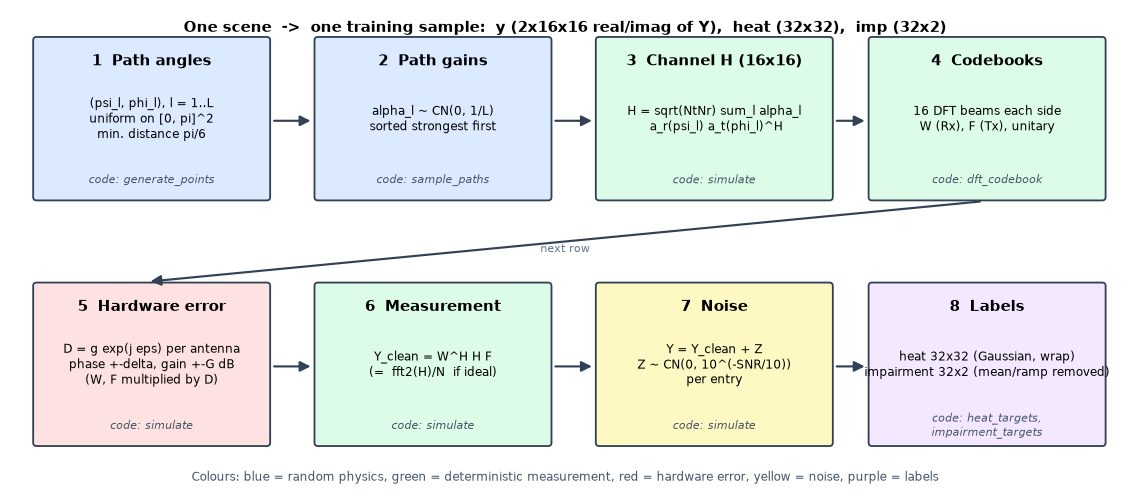

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.6)); ax.set_xlim(0, 13); ax.set_ylim(0, 5.6); ax.axis("off")
boxes = [
 ("1  Path angles", "(psi_l, phi_l), l = 1..L\nuniform on [0, pi]^2\nmin. distance pi/6", "generate_points", "#dbeafe"),
 ("2  Path gains", "alpha_l ~ CN(0, 1/L)\nsorted strongest first", "sample_paths", "#dbeafe"),
 ("3  Channel H (16x16)", "H = sqrt(NtNr) sum_l alpha_l\n a_r(psi_l) a_t(phi_l)^H", "simulate", "#dcfce7"),
 ("4  Codebooks", "16 DFT beams each side\nW (Rx), F (Tx), unitary", "dft_codebook", "#dcfce7"),
 ("5  Hardware error", "D = g exp(j eps) per antenna\nphase +-delta, gain +-G dB\n(W, F multiplied by D)", "simulate", "#fee2e2"),
 ("6  Measurement", "Y_clean = W^H H F\n(=  fft2(H)/N  if ideal)", "simulate", "#dcfce7"),
 ("7  Noise", "Y = Y_clean + Z\nZ ~ CN(0, 10^(-SNR/10))\nper entry", "simulate", "#fef9c3"),
 ("8  Labels", "heat 32x32 (Gaussian, wrap)\nimpairment 32x2 (mean/ramp removed)", "heat_targets,\nimpairment_targets", "#f3e8ff"),
]
pos = [(0.3, 3.4), (3.6, 3.4), (6.9, 3.4), (10.1, 3.4), (0.3, 0.5), (3.6, 0.5), (6.9, 0.5), (10.1, 0.5)]
for (t, f, fn, col), (x, y) in zip(boxes, pos):
    ax.add_patch(FancyBboxPatch((x, y), 2.7, 1.85, boxstyle="round,pad=0.04", fc=col, ec="#334155", lw=1.2))
    ax.text(x + 1.35, y + 1.6, t, ha="center", va="center", fontweight="bold", fontsize=9.5)
    ax.text(x + 1.35, y + 0.92, f, ha="center", va="center", fontsize=8)
    ax.text(x + 1.35, y + 0.2, "code: " + fn, ha="center", va="center", fontsize=7, color="#475569", style="italic")
def arrow(a, b): ax.add_patch(FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=14, lw=1.4, color="#334155"))
for i in range(3): arrow((pos[i][0] + 2.75, pos[i][1] + 0.9), (pos[i + 1][0] - 0.05, pos[i + 1][1] + 0.9))
arrow((11.4, 3.35), (1.6, 2.4)); ax.text(6.5, 2.75, "next row", fontsize=7, color="#64748b", ha="center")
for i in range(4, 7): arrow((pos[i][0] + 2.75, pos[i][1] + 0.9), (pos[i + 1][0] - 0.05, pos[i + 1][1] + 0.9))
ax.text(6.5, 5.35, "One scene  ->  one training sample:  y (2x16x16 real/imag of Y),  heat (32x32),  imp (32x2)", ha="center", fontsize=10, fontweight="bold")
ax.text(6.5, 0.05, "Colours: blue = random physics, green = deterministic measurement, red = hardware error, yellow = noise, purple = labels", ha="center", fontsize=8, color="#475569")
plt.show()

## 2. Step 1 - path angles (the scene)

We fix one scene with **L = 3 paths** (the same L as the official test bank) and seed it, so every figure below is about
*the same* scene. Each path has an AoD $\phi_l$ (transmit side) and an AoA $\psi_l$ (receive side), drawn **uniformly on $[0,\pi]^2$**
by rejection sampling: a new point is rejected if it is closer than $\pi/6$ (30 degrees, Euclidean, in the $(\phi,\psi)$ plane) to any earlier point.

The receiver never sees angles directly; it sees them through the beam grid. Path $l$ appears at the *continuous* beam-grid position

$$q_l = 16\,\frac{\mathrm{wrap}_{2\pi}(-\pi\cos\psi_l)}{2\pi},\qquad p_l = 16\,\frac{\mathrm{wrap}_{2\pi}(\pi\cos\phi_l)}{2\pi}.$$

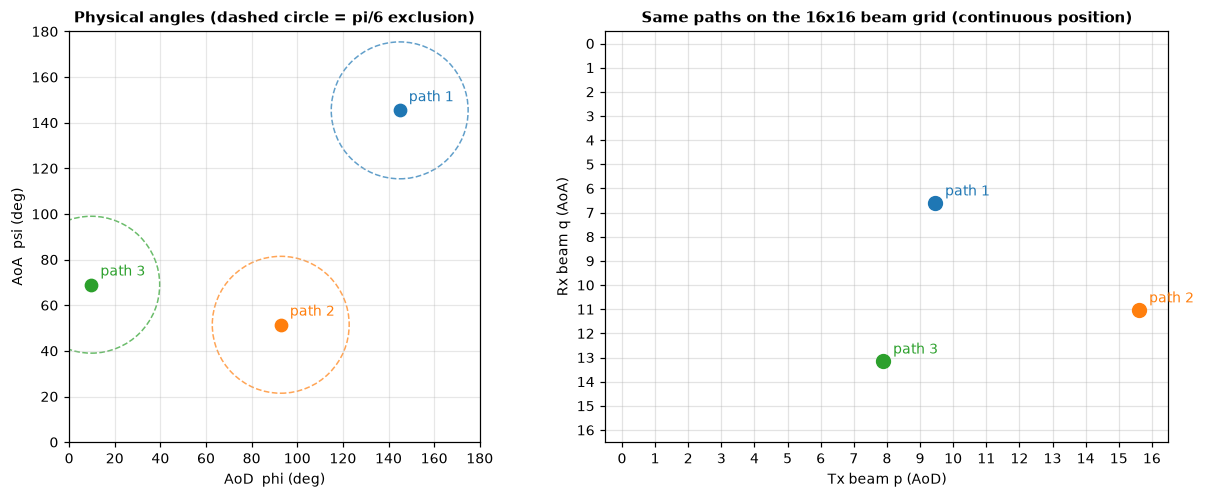

path  psi(AoA)deg  phi(AoD)deg |   q (row)   p (col)   nearest cell
  1      145.43      144.90   |    6.587     9.455    ( 7,  9)
  2       51.44       92.76   |   11.014    15.615    (11,  0)
  3       69.01        9.71   |   13.134     7.885    (13,  8)


In [3]:
SCENE_SEED, L0, SNR0, DELTA0, GAIN0 = 5, 3, 15, 5.0, 3.0
rng = np.random.default_rng(SCENE_SEED)
psi, phi, alpha = sample_paths(np.array([L0]), rng)            # step 1 + 2 (points first, then alpha)
q16, p16 = angles_to_cells(psi[0], phi[0], 16)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.6))
a = ax[0]
for l in range(L0):
    a.add_patch(Circle((np.rad2deg(phi[0, l]), np.rad2deg(psi[0, l])), 30, fill=False, ls="--", color=f"C{l}", alpha=.7))
    a.plot(np.rad2deg(phi[0, l]), np.rad2deg(psi[0, l]), "o", color=f"C{l}", ms=8)
    a.annotate(f"path {l+1}", (np.rad2deg(phi[0, l]) + 4, np.rad2deg(psi[0, l]) + 4), color=f"C{l}")
a.set_xlim(0, 180); a.set_ylim(0, 180); a.set_aspect("equal"); a.set_xlabel("AoD  phi (deg)"); a.set_ylabel("AoA  psi (deg)")
a.set_title("Physical angles (dashed circle = pi/6 exclusion)"); a.grid(alpha=.3)
b = ax[1]
b.set_xlim(-.5, 16.5); b.set_ylim(16.5, -.5); b.set_xticks(range(17)); b.set_yticks(range(17)); b.grid(alpha=.35)
for l in range(L0):
    b.plot(p16[l], q16[l], "o", color=f"C{l}", ms=9); b.annotate(f"path {l+1}", (p16[l] + .3, q16[l] - .3), color=f"C{l}")
b.set_xlabel("Tx beam p (AoD)"); b.set_ylabel("Rx beam q (AoA)"); b.set_title("Same paths on the 16x16 beam grid (continuous position)")
plt.tight_layout(); plt.show()
print("path  psi(AoA)deg  phi(AoD)deg |   q (row)   p (col)   nearest cell")
for l in range(L0):
    print(f"  {l+1}   {np.rad2deg(psi[0,l]):9.2f}   {np.rad2deg(phi[0,l]):9.2f}   | {q16[l]:8.3f}  {p16[l]:8.3f}    ({round(q16[l])%16:2d}, {round(p16[l])%16:2d})")

**Reading it.** Left: three physical directions, no two closer than 30 degrees. Right: where each lands on the receiver's 16x16 beam grid.
Because $u=\pi\cos\psi$ (not $\psi$ itself) sets the position, paths near end-fire ($\psi\approx0$ or $\pi$) are squeezed together and two paths
that are far apart in angle can still fall in the same beam cell (quantified in section 12).

## 3. Step 2 - path gains

Each path gets a complex Rayleigh gain $\alpha_l\sim\mathcal{CN}(0,1/L)$ (total average power 1). The gains are **sorted strongest first**
and paired with the paths in placement order.

In [4]:
print("path   |alpha|   |alpha|^2   phase(deg)   power share")
tot = np.sum(np.abs(alpha[0]) ** 2)
for l in range(L0):
    print(f"  {l+1}    {abs(alpha[0,l]):6.3f}    {abs(alpha[0,l])**2:7.3f}    {np.rad2deg(np.angle(alpha[0,l])):8.1f}    {100*abs(alpha[0,l])**2/tot:6.1f}%")
print(f"sum |alpha|^2 = {tot:.3f}   (expected value 1.0 over many draws)")

path   |alpha|   |alpha|^2   phase(deg)   power share
  1     0.705      0.496       108.7      51.8%
  2     0.589      0.347       -58.7      36.2%
  3     0.339      0.115       160.8      12.0%
sum |alpha|^2 = 0.958   (expected value 1.0 over many draws)


## 4. Step 3 - the antenna-domain channel $H$

Each path is a rank-1 outer product of a receive steering vector and a transmit steering vector, with a half-wavelength ULA:

$$a(\theta)_n=\frac{e^{-j\pi n\cos\theta}}{\sqrt{16}},\qquad H=\sqrt{N_tN_r}\sum_{l=1}^{L}\alpha_l\,a_r(\psi_l)\,a_t(\phi_l)^H .$$

$H$ is a 16x16 complex matrix (Rx antennas x Tx antennas). Its rank equals L.

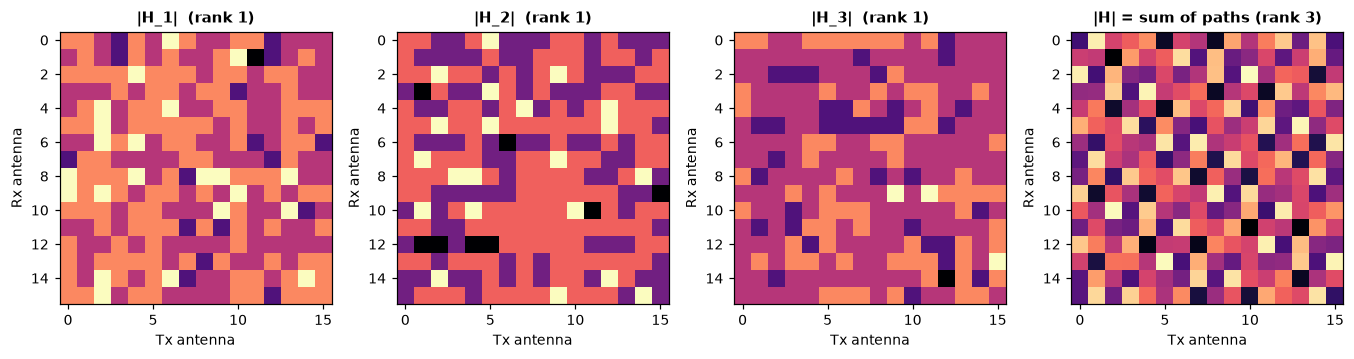

max |H - sum_l H_l| = 4.47545209131181e-16 | singular values of H: [11.448  9.367  5.225  0.     0.   ]


In [5]:
sim = simulate(psi, phi, alpha, SNR0, np.random.default_rng(0))       # ideal hardware (delta = 0, gain = 0)
H = sim["H"][0]
Hl = [np.sqrt(NT * NR) * alpha[0, l] * np.outer(steering(NR, psi[0, l]), np.conj(steering(NT, phi[0, l]))) for l in range(L0)]
fig, ax = plt.subplots(1, L0 + 1, figsize=(3.1 * (L0 + 1), 3.2))
for l in range(L0):
    ax[l].imshow(np.abs(Hl[l]), cmap="magma"); ax[l].set_title(f"|H_{l+1}|  (rank {np.linalg.matrix_rank(Hl[l])})")
ax[L0].imshow(np.abs(H), cmap="magma"); ax[L0].set_title(f"|H| = sum of paths (rank {np.linalg.matrix_rank(H, tol=1e-9)})")
for a_ in ax: a_.set_xlabel("Tx antenna"); a_.set_ylabel("Rx antenna")
plt.tight_layout(); plt.show()
print("max |H - sum_l H_l| =", np.abs(H - sum(Hl)).max(), "| singular values of H:", np.linalg.svd(H, compute_uv=False)[:5])

Every single path has constant magnitude across the array (only its phase changes linearly with the antenna index: that linear phase *is* the angle).
The sum has rank L = 3 (three non-zero singular values).

## 5. Step 4 - the DFT codebooks and the measurement $Y=W^HHF$

The receiver does not read $H$ antenna by antenna. It probes with $P=16$ Tx beams (columns of $F$) and $Q=16$ Rx combiners (columns of $W$),
both **unitary DFT codebooks** (beam centres equally spaced in $\cos\theta$). The measurement is a 16x16 matrix $Y=W^H H F$, so
$Y[q,p]$ is the response of Rx beam $q$ and Tx beam $p$.

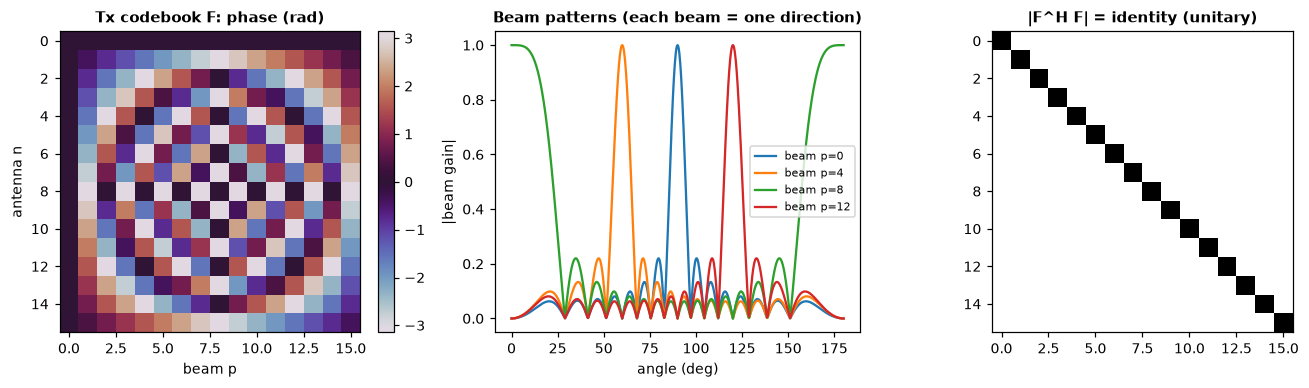

unitarity error  ||F^H F - I|| = 1.7508336394546731e-15   ||W^H W - I|| = 1.7508336394546731e-15
ideal hardware:  max | W^H H F  -  fft2(H)/N | = 5.2697130866910265e-14   -> the measurement is exactly a 2-D DFT of H


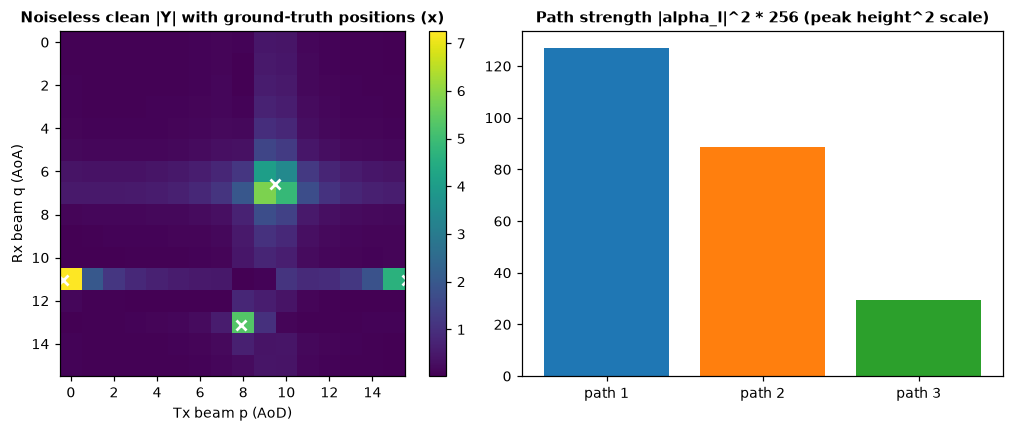

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.6))
im = ax[0].imshow(np.angle(F_IDEAL), cmap="twilight"); ax[0].set_title("Tx codebook F: phase (rad)")
ax[0].set_xlabel("beam p"); ax[0].set_ylabel("antenna n"); plt.colorbar(im, ax=ax[0], fraction=.046)
th = np.linspace(0, np.pi, 721)
for pidx in (0, 4, 8, 12):
    resp = np.abs(F_IDEAL[:, pidx].conj() @ steering(NT, th).T) if False else np.abs(steering(NT, th) @ np.conj(F_IDEAL[:, pidx]))
    ax[1].plot(np.rad2deg(th), resp, label=f"beam p={pidx}")
ax[1].set_xlabel("angle (deg)"); ax[1].set_ylabel("|beam gain|"); ax[1].set_title("Beam patterns (each beam = one direction)"); ax[1].legend(fontsize=7)
ax[2].imshow(np.abs(F_IDEAL.conj().T @ F_IDEAL), cmap="gray_r"); ax[2].set_title("|F^H F| = identity (unitary)")
plt.tight_layout(); plt.show()
print("unitarity error  ||F^H F - I|| =", np.abs(F_IDEAL.conj().T @ F_IDEAL - np.eye(P)).max(), "  ||W^H W - I|| =", np.abs(W_IDEAL.conj().T @ W_IDEAL - np.eye(Q)).max())

Y_ideal = sim["Y_ideal"][0]
print("ideal hardware:  max | W^H H F  -  fft2(H)/N | =", np.abs(Y_ideal - np.fft.fft2(H) / N).max(), "  -> the measurement is exactly a 2-D DFT of H")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = show_Y(ax[0], Y_ideal, "Noiseless clean |Y| with ground-truth positions (x)", q16, p16); plt.colorbar(im0, ax=ax[0], fraction=.046)
ax[1].bar(range(L0), [abs(alpha[0, l]) ** 2 * NT * NR / 1 for l in range(L0)], color=[f"C{l}" for l in range(L0)])
ax[1].set_xticks(range(L0)); ax[1].set_xticklabels([f"path {l+1}" for l in range(L0)]); ax[1].set_title("Path strength |alpha_l|^2 * 256 (peak height^2 scale)")
plt.tight_layout(); plt.show()

With ideal hardware $Y=\mathrm{fft2}(H)/N$ exactly, so each path is a **peak at its beam position** $(q_l,p_l)$ (white x). A path that falls between two beams
leaks into its neighbours (scalloping); that is the reason the labels use a Gaussian blob and not a single pixel.

## 6. Step 5 - hardware impairment

Real arrays have per-antenna phase-shifter and gain errors. The project models them as a complex factor multiplying **every antenna weight** of both codebooks:

$$D_r=g_r\,e^{j\varepsilon_r},\quad D_t=g_t\,e^{j\varepsilon_t},\qquad W=D_r\odot W_{\rm ideal},\quad F=D_t\odot F_{\rm ideal}.$$

* phase error $\varepsilon\sim U(-\delta,+\delta)$ per antenna (this part follows the base paper's model, $\delta\in\{1,2,5,\dots\}$ degrees);
* gain error $20\log_{10}g\sim U(-G,+G)$ dB per antenna (**an extension added by this project**, neither cited paper models it);
* independent for each of the 16 Rx and 16 Tx antennas, the same for all beams, redrawn for every sample.

Below: the same scene with $\delta=5^\circ$ and $G=3$ dB.

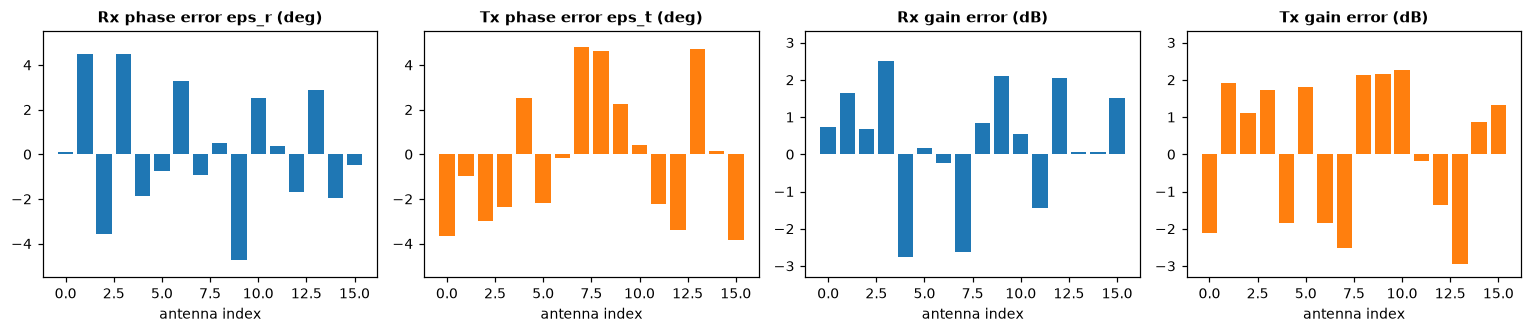

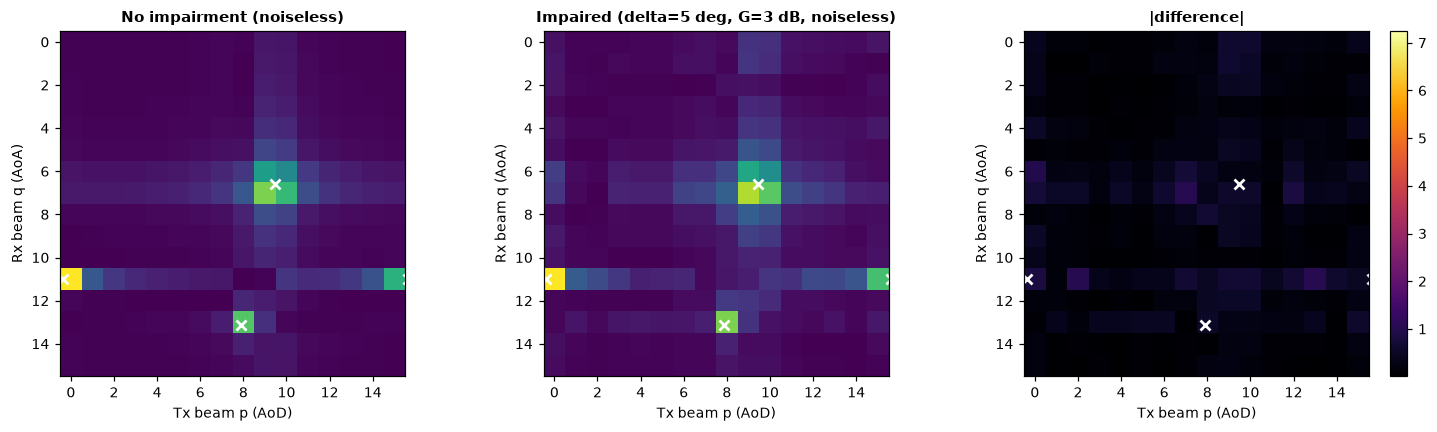

relative change ||Y_imp - Y_ideal|| / ||Y_ideal|| = 0.316   (-10.0 dB)


In [7]:
sim_i = simulate(psi, phi, alpha, SNR0, np.random.default_rng(1), phase_deg_max=DELTA0, gain_db_max=GAIN0)
D_r, D_t = sim_i["D_r"][0], sim_i["D_t"][0]
fig, ax = plt.subplots(1, 4, figsize=(14, 3.1))
ax[0].bar(range(16), np.rad2deg(np.angle(D_r))); ax[0].set_title("Rx phase error eps_r (deg)"); ax[0].set_ylim(-DELTA0 * 1.1, DELTA0 * 1.1)
ax[1].bar(range(16), np.rad2deg(np.angle(D_t)), color="C1"); ax[1].set_title("Tx phase error eps_t (deg)"); ax[1].set_ylim(-DELTA0 * 1.1, DELTA0 * 1.1)
ax[2].bar(range(16), 20 * np.log10(np.abs(D_r))); ax[2].set_title("Rx gain error (dB)"); ax[2].set_ylim(-GAIN0 * 1.1, GAIN0 * 1.1)
ax[3].bar(range(16), 20 * np.log10(np.abs(D_t)), color="C1"); ax[3].set_title("Tx gain error (dB)"); ax[3].set_ylim(-GAIN0 * 1.1, GAIN0 * 1.1)
for a_ in ax: a_.set_xlabel("antenna index")
plt.tight_layout(); plt.show()

Y_imp = sim_i["Y_imp"][0]
vmax = np.abs(Y_ideal).max()
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4))
show_Y(ax[0], Y_ideal, "No impairment (noiseless)", q16, p16, vmax=vmax)
show_Y(ax[1], Y_imp, f"Impaired (delta={DELTA0:g} deg, G={GAIN0:g} dB, noiseless)", q16, p16, vmax=vmax)
im = show_Y(ax[2], Y_imp - Y_ideal, "|difference|", q16, p16, cmap="inferno", vmax=vmax); plt.colorbar(im, ax=ax[2], fraction=.046)
plt.tight_layout(); plt.show()
rel = np.linalg.norm(Y_imp - Y_ideal) / np.linalg.norm(Y_ideal)
print(f"relative change ||Y_imp - Y_ideal|| / ||Y_ideal|| = {rel:.3f}   ({20*np.log10(rel):.1f} dB)")

Phase and gain errors do not move the peaks noticeably; they **leak energy from each path into neighbouring beams** (the difference panel) and
change the peak heights. Small phase errors alone (1-2 degrees) are almost invisible (about -37 dB and -31 dB relative leakage); the network has to cope with the larger, mixed cases.

## 7. Step 6 - additive noise and the final input $Y$

White complex Gaussian noise is added **after** the combiner, one independent draw per beam pair:

$$Y = W^HHF + Z,\qquad Z_{qp}\sim\mathcal{CN}\!\big(0,\;10^{-\mathrm{SNR}/10}\big)$$

(real and imaginary parts each have variance $10^{-\mathrm{SNR}/10}/2$). Because $\sum_l E|\alpha_l|^2=1$ and $W,F$ are unitary, the *average* signal power per entry is 1, so SNR is
a per-entry ratio. We use the **same noise realisation** for the clean and impaired version so that the only difference between them is the hardware error.

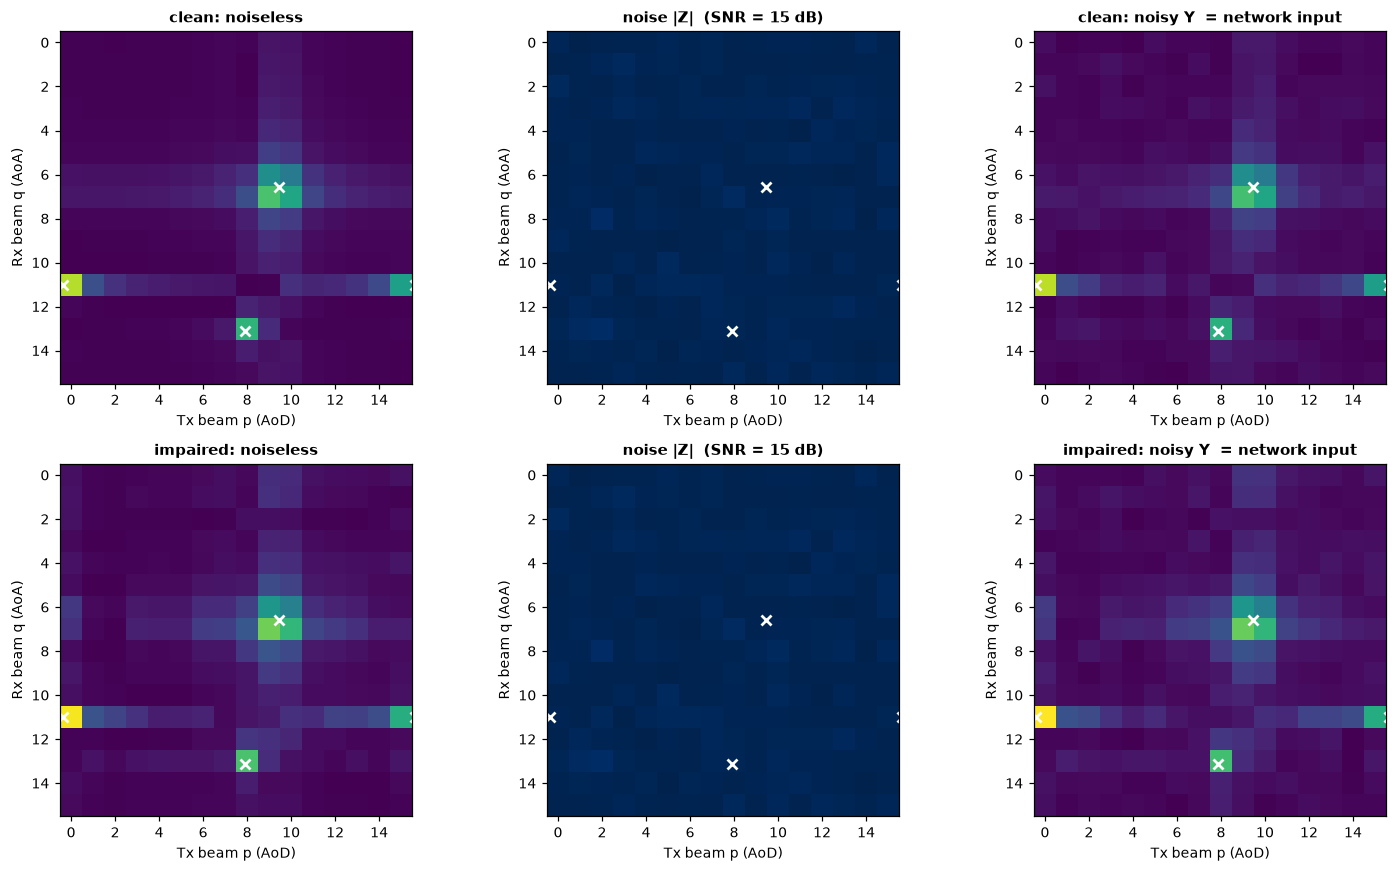

noise power per entry  mean|Z|^2 = 0.0281   (target 10^(-15/10) = 0.0316)
signal power per entry mean|Y_ideal|^2 = 0.9613   (expected ~1 = sum|alpha|^2 = 0.958)
this scene, realised SNR = 15.3 dB  (nominal 15 dB)


In [8]:
pair = {}
for name, pdm, gdm, imp_arg in [("clean", 0.0, 0.0, None), ("impaired", DELTA0, GAIN0, sim_i["unit_imp"])]:
    pair[name] = simulate(psi, phi, alpha, SNR0, None, phase_deg_max=pdm, gain_db_max=gdm,
                          unit_imp=imp_arg if imp_arg is not None else sim_i["unit_imp"], unit_noise=sim_i["unit_noise"])
vmax = max(np.abs(pair["clean"]["Y"]).max(), np.abs(pair["impaired"]["Y"]).max())
fig, ax = plt.subplots(2, 3, figsize=(13.5, 8))
for r, name in enumerate(["clean", "impaired"]):
    s = pair[name]
    show_Y(ax[r, 0], s["Y_imp"][0], f"{name}: noiseless", q16, p16, vmax=vmax)
    im = show_Y(ax[r, 1], s["Z"][0], f"noise |Z|  (SNR = {SNR0} dB)", q16, p16, cmap="cividis", vmax=vmax)
    show_Y(ax[r, 2], s["Y"][0], f"{name}: noisy Y  = network input", q16, p16, vmax=vmax)
plt.tight_layout(); plt.show()
Zc = pair["clean"]["Z"][0]
print(f"noise power per entry  mean|Z|^2 = {np.mean(np.abs(Zc)**2):.4f}   (target 10^(-{SNR0}/10) = {10**(-SNR0/10):.4f})")
print(f"signal power per entry mean|Y_ideal|^2 = {np.mean(np.abs(Y_ideal)**2):.4f}   (expected ~1 = sum|alpha|^2 = {tot:.3f})")
print(f"this scene, realised SNR = {10*np.log10(np.mean(np.abs(Y_ideal)**2)/np.mean(np.abs(Zc)**2)):.1f} dB  (nominal {SNR0} dB)")

## 8. Step 7 - the ground truth (what the network must output)

Two labels are made for every sample.

**(a) Heatmap, 32x32.** For every path, the continuous position $(q_l,p_l)$ is computed on a **32x32 grid** (twice the 16x16 measurement grid, so the
network can localise between beams), rounded to the nearest cell, and a Gaussian blob ($\sigma$ = 1 cell) with peak exactly 1 is placed there.
Distances are **circular** (wrap-around), because beam-space is periodic. Overlapping paths are merged with `max`. Rows are AoA, columns are AoD.

**(b) Impairment vector, 32x2.** For each of the 32 antennas (16 Rx then 16 Tx): the true phase error and the true log-gain error.
The parts that *cannot* be identified from data are removed first: the mean (a common phase/gain) and, for phase, the **linear ramp** (a linear phase across the array is indistinguishable from a shift of the arrival angle).

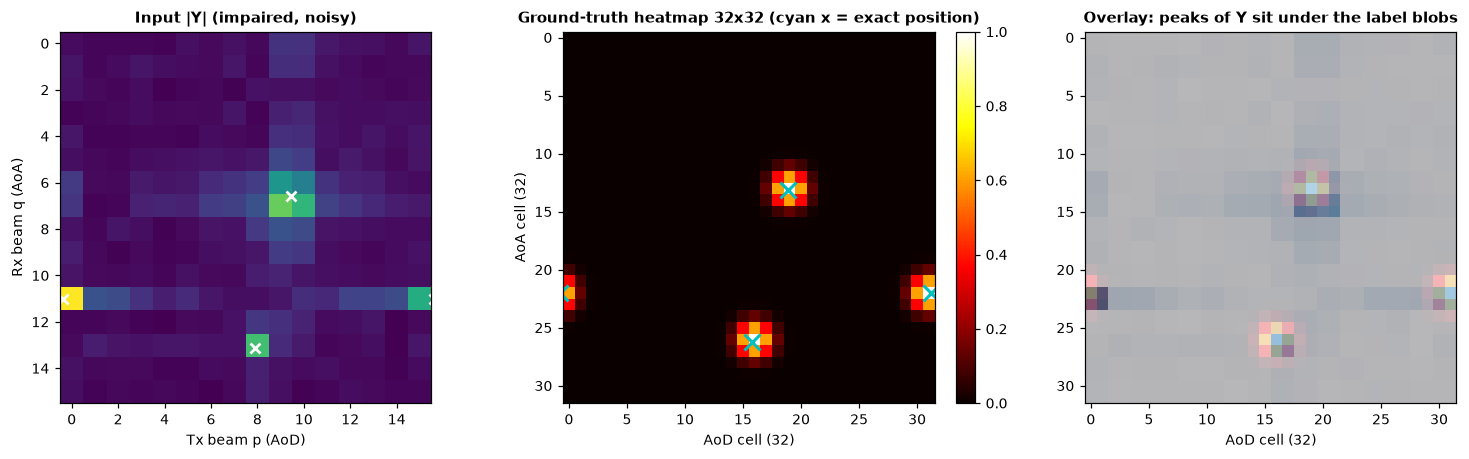

heat: shape (32, 32) | max 1.0 | #cells >= 0.99: 3 (one per path unless two paths round to the same cell)
wrap example: row position 31.68 on the 32-grid -> blob occupies rows [0, 1, 31]  (rows 0,1 and 31: circular distance)


In [9]:
G = CFG["grid"]
heat = heat_targets(psi, phi, G, CFG["heat_sigma"])[0]
q32, p32 = angles_to_cells(psi[0], phi[0], G)
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
show_Y(ax[0], pair["impaired"]["Y"][0], "Input |Y| (impaired, noisy)", q16, p16)
im = ax[1].imshow(heat, cmap="hot", extent=(-.5, G - .5, G - .5, -.5), vmin=0, vmax=1)
mark(ax[1], q32, p32, G, color="c", ms=10, mew=2); ax[1].set_title("Ground-truth heatmap 32x32 (cyan x = exact position)")
ax[1].set_xlabel("AoD cell (32)"); ax[1].set_ylabel("AoA cell (32)"); plt.colorbar(im, ax=ax[1], fraction=.046)
ax[2].imshow(heat, cmap="hot", extent=(-.5, G - .5, G - .5, -.5), vmin=0, vmax=1, alpha=.55)
ax[2].imshow(np.kron(np.abs(pair["impaired"]["Y"][0]), np.ones((2, 2))), cmap="Blues", extent=(-.5, G - .5, G - .5, -.5), alpha=.5)
ax[2].set_title("Overlay: peaks of Y sit under the label blobs"); ax[2].set_xlabel("AoD cell (32)")
plt.tight_layout(); plt.show()
print("heat: shape", heat.shape, "| max", heat.max(), "| #cells >= 0.99:", int((heat >= 0.99).sum()), "(one per path unless two paths round to the same cell)")

# wrap-around illustration: a path whose row position is ~0 spills its blob onto the last rows
psi_e = np.array([[np.arccos(0.02)]]); phi_e = np.array([[np.pi / 3]])
q_e, _ = angles_to_cells(psi_e[0, 0], phi_e[0, 0], G)
h_edge = heat_targets(psi_e, phi_e, G, 1.0)[0]
rows = [int(r) for r in np.where(h_edge.max(1) > 0.3)[0]]
print(f"wrap example: row position {float(q_e):.2f} on the 32-grid -> blob occupies rows {rows}  (rows 0,1 and 31: circular distance)")

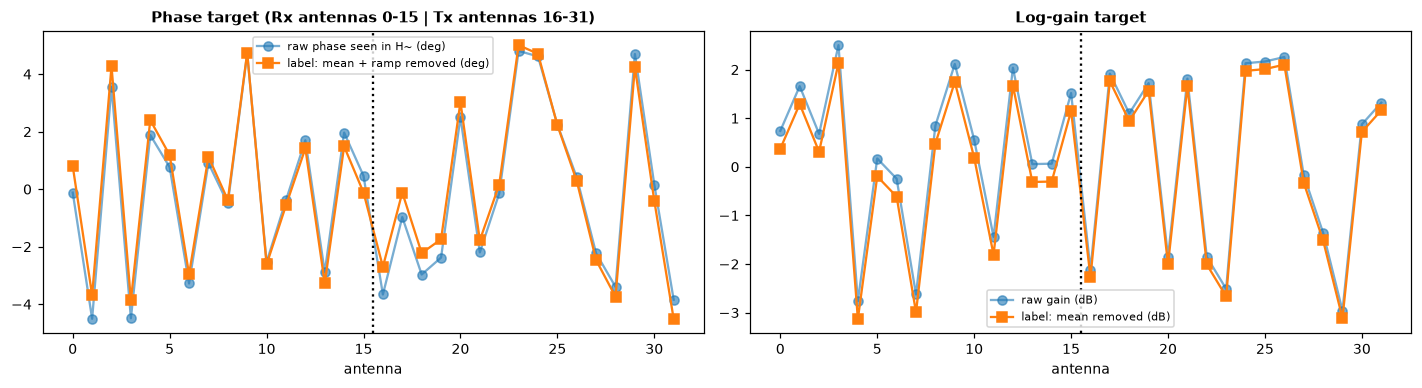

label check: Rx phase mean = -0.0 | Rx phase slope = 2e-09 | Tx phase mean = 0.0 | slope = 2.4e-08


In [10]:
tgt_raw = np.concatenate([-np.angle(D_r), np.angle(D_t)]); lg_raw = np.log(np.abs(np.concatenate([D_r, D_t])))
tgt = impairment_targets(sim_i["D_r"], sim_i["D_t"])[0]          # (32, 2): [:,0] phase, [:,1] log-gain
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
x = np.arange(32)
ax[0].plot(x, np.rad2deg(tgt_raw), "o-", label="raw phase seen in H~ (deg)", alpha=.6)
ax[0].plot(x, np.rad2deg(tgt[:, 0]), "s-", label="label: mean + ramp removed (deg)")
ax[0].axvline(15.5, color="k", ls=":"); ax[0].set_title("Phase target (Rx antennas 0-15 | Tx antennas 16-31)"); ax[0].legend(fontsize=7); ax[0].set_xlabel("antenna")
ax[1].plot(x, 20 / np.log(10) * lg_raw, "o-", label="raw gain (dB)", alpha=.6)
ax[1].plot(x, 20 / np.log(10) * tgt[:, 1], "s-", label="label: mean removed (dB)")
ax[1].axvline(15.5, color="k", ls=":"); ax[1].set_title("Log-gain target"); ax[1].legend(fontsize=7); ax[1].set_xlabel("antenna")
plt.tight_layout(); plt.show()
n_ = np.arange(16) - 7.5
print("label check: Rx phase mean =", tgt[:16, 0].mean().round(9), "| Rx phase slope =", (tgt[:16, 0] @ n_).round(9),
      "| Tx phase mean =", tgt[16:, 0].mean().round(9), "| slope =", (tgt[16:, 0] @ n_).round(9))

## 9. No impairment versus impairment, across SNR

Same scene, same impairment *shape*, same noise *shape*; only the strengths change (rows: SNR, columns: hardware error). White x = ground truth.
This is the picture to keep in mind: at low SNR the paths sink into noise, and at high SNR the impairment leakage becomes visible around the peaks.

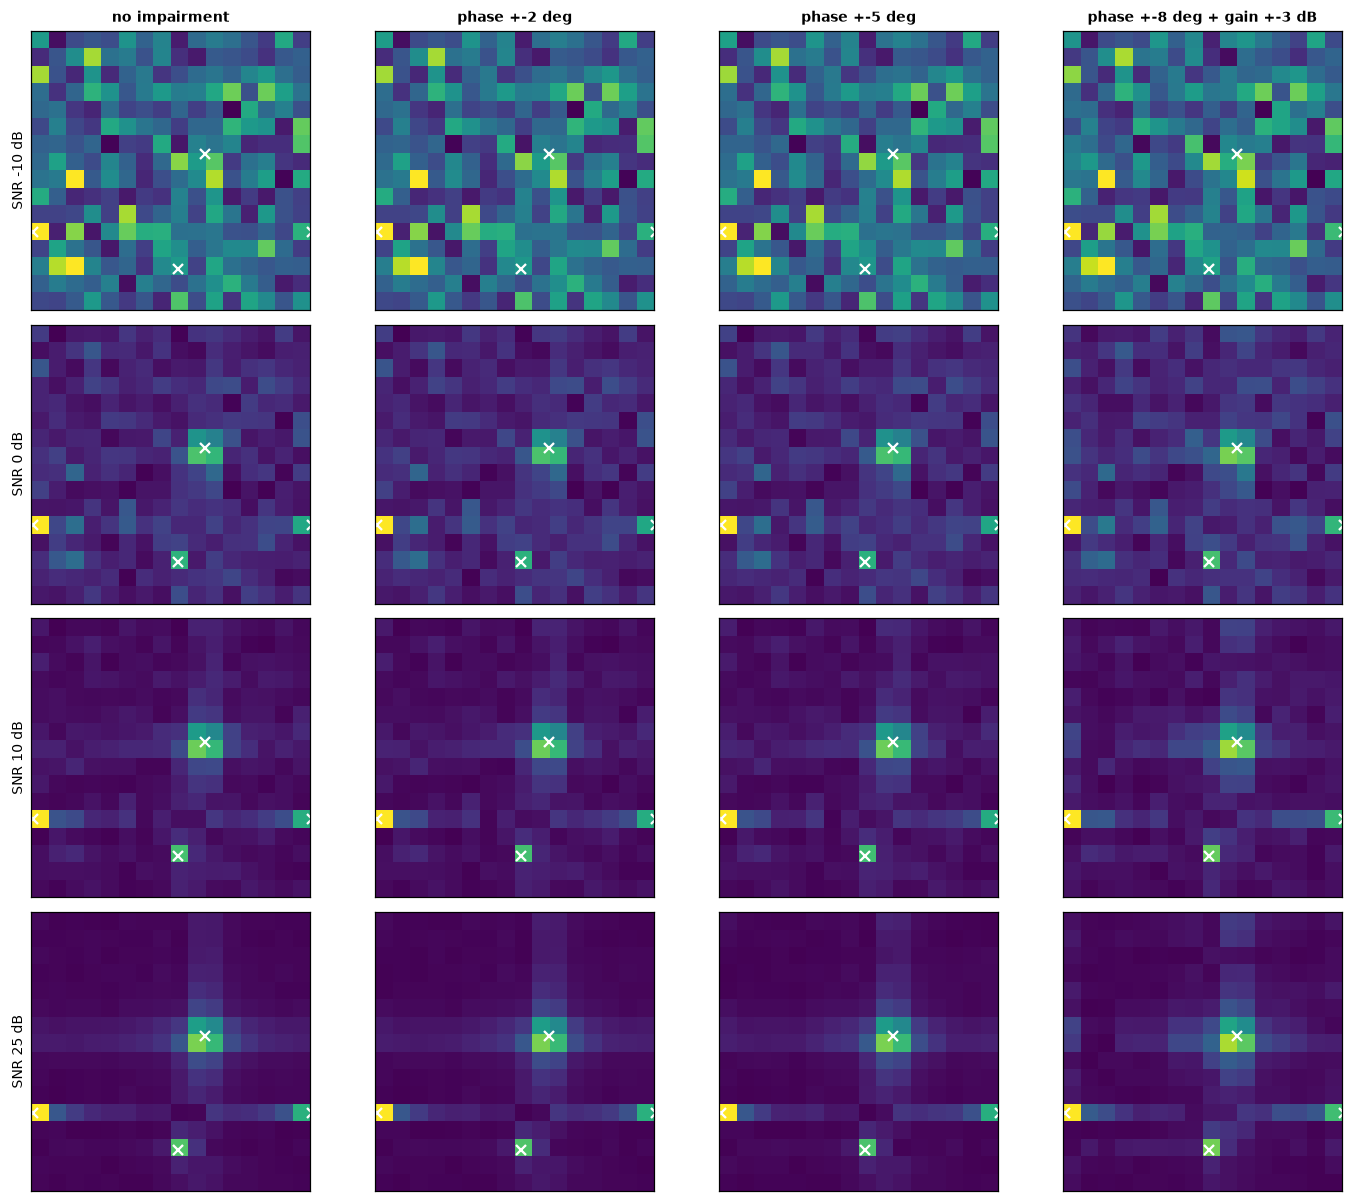

In [11]:
snrs = [-10, 0, 10, 25]
cols = [("no impairment", 0.0, 0.0), ("phase +-2 deg", 2.0, 0.0), ("phase +-5 deg", 5.0, 0.0), ("phase +-8 deg + gain +-3 dB", 8.0, 3.0)]
fig, ax = plt.subplots(len(snrs), len(cols), figsize=(13, 11))
ref = simulate(psi, phi, alpha, 100, None, unit_imp=sim_i["unit_imp"], unit_noise=sim_i["unit_noise"])["Y_ideal"][0]
for i, s in enumerate(snrs):
    for j, (nm, pdm, gdm) in enumerate(cols):
        Y = simulate(psi, phi, alpha, s, None, phase_deg_max=pdm, gain_db_max=gdm, unit_imp=sim_i["unit_imp"], unit_noise=sim_i["unit_noise"])["Y"][0]
        a_ = ax[i, j]; a_.imshow(np.abs(Y), cmap="viridis", extent=(-.5, 15.5, 15.5, -.5), vmax=np.abs(ref).max())
        mark(a_, q16, p16, 16, ms=6, mew=1.5); a_.set_xticks([]); a_.set_yticks([])
        if i == 0: a_.set_title(nm, fontsize=9)
        if j == 0: a_.set_ylabel(f"SNR {s} dB")
plt.tight_layout(); plt.show()

## 10. Exactly what one training sample is (tensors)

A training sample is the triple **(y, heat, imp)**. `y` is the 16x16 complex `Y` split into real and imaginary planes. Inside the network (not part of the dataset),
`Y` is first passed through the impairment-correcting front end, then divided by its RMS, and a third channel $\log(|Y_n|^2+10^{-3})$ is appended.
Below that final 3-channel view is shown for the impaired noisy scene, because the log channel is what makes weak paths visible at low SNR.

one batch of 4 (training recipe):
  y     shape (4, 2, 16, 16)  dtype float32   range [-7.824, 13.914]
  heat  shape (4, 32, 32)  dtype float32   range [0.000, 1.000]
  imp   shape (4, 32, 2)  dtype float32   range [-0.274, 0.235]
  meta  L = [1 7 6 1] | SNR = [21. -7. -5. -8.] | clean = [ True False False False] | phase max = [0.   7.12 4.1  1.96] | gain max = [0.   0.64 2.22 1.89]


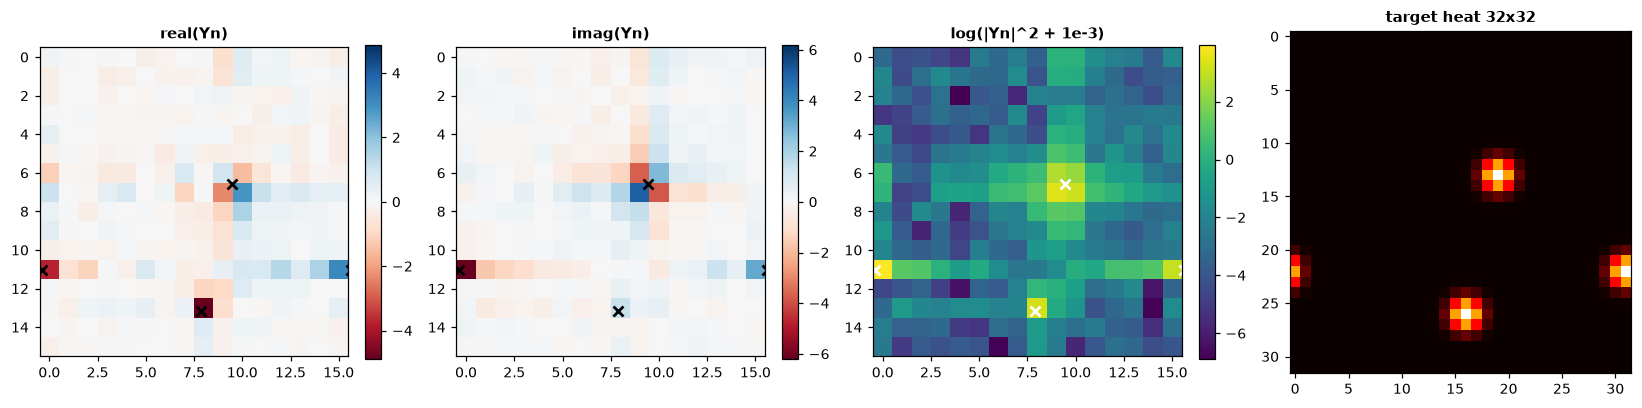

In [12]:
b = make_batch(np.random.default_rng(123), 4)
print("one batch of 4 (training recipe):")
for k in ("y", "heat", "imp"): print(f"  {k:5s} shape {tuple(b[k].shape)}  dtype {b[k].dtype}   range [{b[k].min():.3f}, {b[k].max():.3f}]")
print("  meta  L =", b["L"], "| SNR =", b["snr"], "| clean =", b["clean"], "| phase max =", b["pd"].round(2), "| gain max =", b["gd"].round(2))

Yn_src = pair["impaired"]["Y"][0]
Yn = Yn_src / (np.sqrt(np.mean(np.abs(Yn_src) ** 2)) + 1e-8)
chans = [("real(Yn)", Yn.real, "RdBu"), ("imag(Yn)", Yn.imag, "RdBu"), ("log(|Yn|^2 + 1e-3)", np.log(np.abs(Yn) ** 2 + 1e-3), "viridis")]
fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
for a_, (t, im_, cm) in zip(ax, chans):
    v = np.abs(im_).max() if cm == "RdBu" else None
    h = a_.imshow(im_, cmap=cm, vmin=-v if v else None, vmax=v, extent=(-.5, 15.5, 15.5, -.5)); a_.set_title(t); plt.colorbar(h, ax=a_, fraction=.046)
    mark(a_, q16, p16, 16, color="k" if cm == "RdBu" else "w", ms=6)
ax[3].imshow(heat, cmap="hot", extent=(-.5, 31.5, 31.5, -.5)); ax[3].set_title("target heat 32x32")
plt.tight_layout(); plt.show()

## 11. The training stream as a whole

Every training step draws a fresh batch with `make_batch`: L uniform in 1..9, SNR uniform integer in [-15, 24] dB, **20 % of samples are completely clean**,
and for the other 80 % the phase limit is $U(0,8^\circ)$ and the gain limit $U(0,3\,\mathrm{dB})$. Below: 3,000 samples from that recipe.

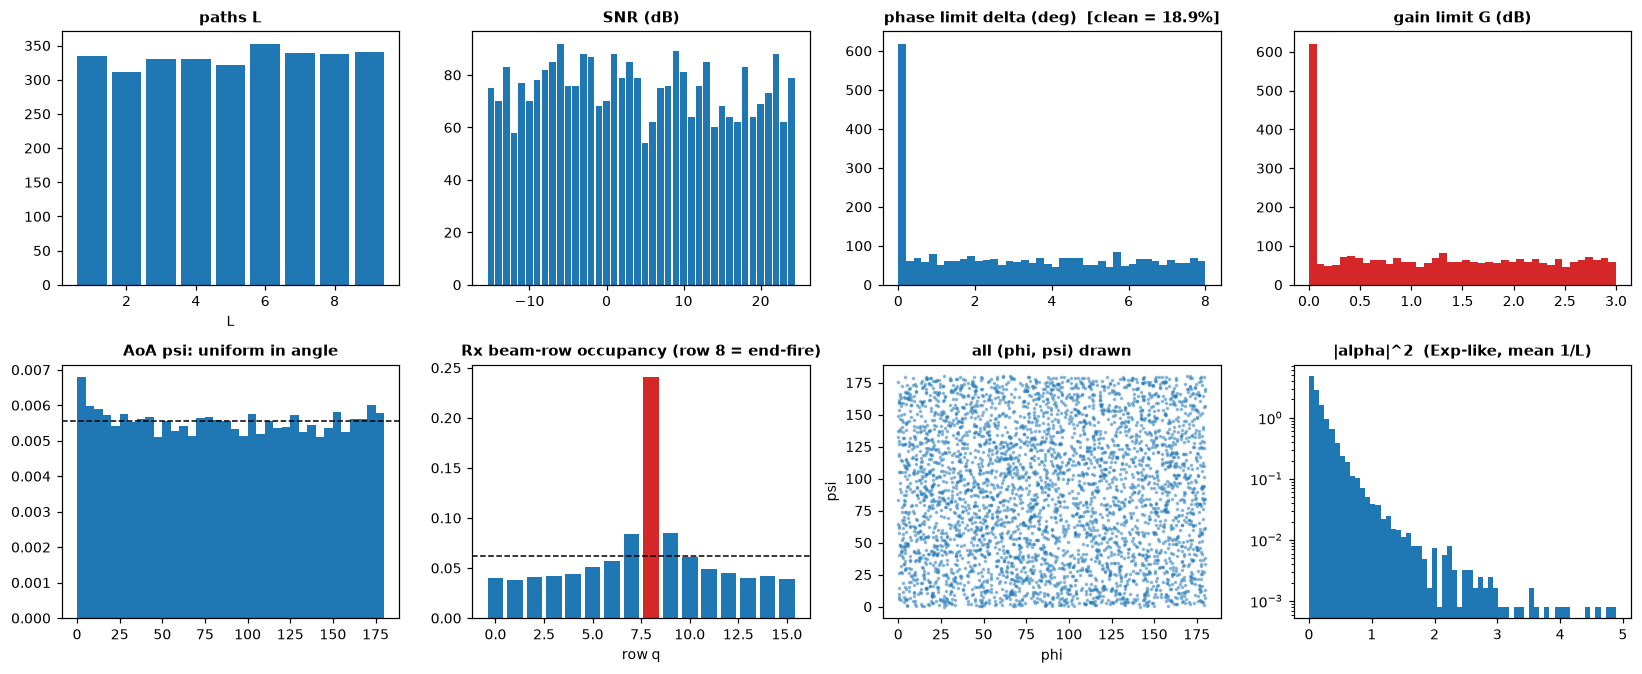

mean L = 5.05, clean fraction = 0.189, occupancy of end-fire row 8 = 24.1% vs uniform 6.25%
number of training samples in the real run = 48000 x 256 = 12,288,000 (fresh each step, never stored)


In [13]:
t = make_batch(np.random.default_rng(2026), 3000)
fig, ax = plt.subplots(2, 4, figsize=(15, 6.2))
ax[0, 0].hist(t["L"], bins=np.arange(0.5, 10.5, 1), rwidth=.85); ax[0, 0].set_title("paths L"); ax[0, 0].set_xlabel("L")
ax[0, 1].hist(t["snr"], bins=np.arange(-15.5, 25.5, 1), rwidth=.85); ax[0, 1].set_title("SNR (dB)")
ax[0, 2].hist(t["pd"], bins=40); ax[0, 2].set_title(f"phase limit delta (deg)  [clean = {100*t['clean'].mean():.1f}%]")
ax[0, 3].hist(t["gd"], bins=40, color="C3"); ax[0, 3].set_title("gain limit G (dB)")
valid = ~np.isnan(t["psi"])
ax[1, 0].hist(np.rad2deg(t["psi"][valid]), bins=36, density=True); ax[1, 0].set_title("AoA psi: uniform in angle")
ax[1, 0].axhline(1 / 180, color="k", ls="--", lw=1)
qs, ps_ = angles_to_cells(t["psi"][valid], t["phi"][valid], 16)
occ = np.bincount(np.round(qs).astype(int) % 16, minlength=16) / valid.sum()
ax[1, 1].bar(range(16), occ, color=["C3" if k == 8 else "C0" for k in range(16)]); ax[1, 1].axhline(1 / 16, color="k", ls="--", lw=1)
ax[1, 1].set_title("Rx beam-row occupancy (row 8 = end-fire)"); ax[1, 1].set_xlabel("row q")
ax[1, 2].scatter(np.rad2deg(t["phi"][valid])[:4000], np.rad2deg(t["psi"][valid])[:4000], s=2, alpha=.4); ax[1, 2].set_title("all (phi, psi) drawn")
ax[1, 2].set_xlabel("phi"); ax[1, 2].set_ylabel("psi")
ax[1, 3].hist(np.abs(t["alpha"][valid]) ** 2, bins=60, density=True); ax[1, 3].set_title("|alpha|^2  (Exp-like, mean 1/L)"); ax[1, 3].set_yscale("log")
plt.tight_layout(); plt.show()
print(f"mean L = {t['L'].mean():.2f}, clean fraction = {t['clean'].mean():.3f}, occupancy of end-fire row 8 = {100*occ[8]:.1f}% vs uniform 6.25%")
print(f"number of training samples in the real run = {CFG['steps']} x {CFG['batch']} = {CFG['steps']*CFG['batch']:,} (fresh each step, never stored)")

**Why row 8 (end-fire) is over-full.** Angles are uniform in $\psi$, but the beam position depends on $\cos\psi$, which follows an arcsine law and piles up near $\psi=0$ and $\pi$.
About 22-24 % of paths land in the single end-fire beam row, roughly 3.6-3.9 times more than uniform.

Two measurable side-effects for **L = 3** (the official test scenario), computed below over 20,000 fresh scenes:

In [14]:
rng3 = np.random.default_rng(77); n3 = 20000
psi3, phi3, al3 = sample_paths(np.full(n3, 3), rng3)
q3, p3 = angles_to_cells(psi3, phi3, 16); q32_, p32_ = angles_to_cells(psi3, phi3, 32)
circ = lambda d, n: np.minimum(np.abs(d), n - np.abs(d))
close = np.zeros(n3, bool); merged = np.zeros(n3, bool)
for i in range(3):
    for j in range(i + 1, 3):
        close |= (circ(q3[:, i] - q3[:, j], 16) < 1) & (circ(p3[:, i] - p3[:, j], 16) < 1)
        merged |= (np.round(q32_[:, i]) % 32 == np.round(q32_[:, j]) % 32) & (np.round(p32_[:, i]) % 32 == np.round(p32_[:, j]) % 32)
print(f"scenes with two paths closer than one beam cell (both axes, wrap-aware) : {100*close.mean():.2f}%   (audit: 3.8-3.9%)")
print(f"scenes where two paths round to the SAME 32x32 label cell                : {100*merged.mean():.2f}%   (audit: 0.33-0.37%)")

scenes with two paths closer than one beam cell (both axes, wrap-aware) : 4.10%   (audit: 3.8-3.9%)
scenes where two paths round to the SAME 32x32 label cell                : 0.40%   (audit: 0.33-0.37%)


## 12. The frozen evaluation banks (the only stored data)

| Bank | Samples | L | SNR (dB) | Impairment | Seed | Notes |
|---|---|---|---|---|---|---|
| `official` (`eval_bank.npz`) | 8,000 (1,000 per SNR) | 3 | -10..25 step 5 | none | 42 | the authors' `validation_data_generator`, reproduced bit-exactly; same bank used for U-Net |
| `dldoa_dataset/test` | 8,000 | 3 | -10..25 | none | 7 | second independent draw; not used for design |
| `T2_d1`, `T2_d2`, `T2_d5` | 8,000 each | 3 | -10..25 | phase-only, delta = 1, 2, 5 deg | 9101, 9102, 9105 | paper Table-2 protocol; 1 and 2 deg are almost clean |
| tuning banks | about 1,500 total | mixed | mixed | mixed | 9901-9904 | used **only** to tune self-calibration (lam, tau) |
| v1 robustness banks | 47 x 500 | 3 | various | phase / gain / SNR sweeps | various | re-used read-only from the v1 suite |
| **training** | **12,288,000 fresh scenes** | 1..9 | -15..24 | 20 % clean, else delta<=8 deg, G<=3 dB | os.urandom | never stored, never repeated |

Test banks are generated with the **same simulator** but different seeds and a narrower, single-L protocol, so training never sees a test scene.

## 13. Self-checks and comparison with the project code

In [15]:
checks = []
def chk(name, ok, detail=""): checks.append((name, bool(ok), detail)); print(("PASS  " if ok else "FAIL  ") + name, detail)

chk("codebooks unitary", np.abs(F_IDEAL.conj().T @ F_IDEAL - np.eye(P)).max() < 1e-12 and np.abs(W_IDEAL.conj().T @ W_IDEAL - np.eye(Q)).max() < 1e-12)
chk("Y_ideal == fft2(H)/N", np.abs(Y_ideal - np.fft.fft2(H) / N).max() < 1e-12)
chk("H has rank L", np.linalg.matrix_rank(H, tol=1e-9) == L0)

# noise level: many draws
rb = np.random.default_rng(9)
ps_, ph_, al_ = sample_paths(np.full(3000, 3), rb)
s10 = simulate(ps_, ph_, al_, 10.0, rb)
ratio = np.mean(np.abs(s10["Y_ideal"]) ** 2) / np.mean(np.abs(s10["Z"]) ** 2)
chk("realised SNR ~ nominal (10 dB, 3000 scenes)", abs(10 * np.log10(ratio) - 10) < 0.3, f"[{10*np.log10(ratio):.2f} dB]")

# impairment statistics
si = simulate(ps_, ph_, al_, 10.0, rb, phase_deg_max=5.0, gain_db_max=3.0)
chk("phase error uniform within +-delta", np.abs(np.angle(si["D_r"])).max() <= np.deg2rad(5.0) + 1e-9)
chk("gain error within +-G dB", np.abs(20 * np.log10(np.abs(si["D_t"]))).max() <= 3.0 + 1e-9)
tg = impairment_targets(si["D_r"], si["D_t"])
nn = np.arange(16) - 7.5
chk("impairment label has zero mean and zero ramp", np.abs(tg[:, :16, 0].mean(1)).max() < 1e-6 and np.abs(tg[:, :16, 0] @ nn).max() < 1e-5 and np.abs(tg[:, 16:, 0] @ nn).max() < 1e-5)

# heat labels
hh = heat_targets(ps_, ph_, 32, 1.0)
chk("heat peak is exactly 1 in every scene", np.allclose(hh.reshape(len(hh), -1).max(1), 1.0))
chk("heat in [0,1]", hh.min() >= 0 and hh.max() <= 1.0)

# label vs data consistency: at very high SNR, every strong path should show a peak near its cell
s_hi = simulate(ps_[:500], ph_[:500], al_[:500], 60.0, rb)
hit = tot_ = 0
for i in range(500):
    Y = np.abs(s_hi["Y"][i]); qq, pp = angles_to_cells(ps_[i], ph_[i], 16)
    top = np.unravel_index(np.argmax(Y), Y.shape)
    d = np.minimum(np.abs(np.array(top)[None, :] - np.stack([qq, pp], 1)), 16 - np.abs(np.array(top)[None, :] - np.stack([qq, pp], 1))).max(1)
    hit += (d.min() <= 1.0); tot_ += 1
chk("strongest bin of Y lies within 1 cell of a ground-truth path (60 dB)", hit / tot_ > 0.98, f"[{100*hit/tot_:.1f}% of scenes]")
print("\n", sum(c[1] for c in checks), "/", len(checks), "checks passed")

PASS  codebooks unitary 
PASS  Y_ideal == fft2(H)/N 
PASS  H has rank L 


PASS  realised SNR ~ nominal (10 dB, 3000 scenes) [10.01 dB]


PASS  phase error uniform within +-delta 
PASS  gain error within +-G dB 
PASS  impairment label has zero mean and zero ramp 
PASS  heat peak is exactly 1 in every scene 
PASS  heat in [0,1] 


PASS  strongest bin of Y lies within 1 cell of a ground-truth path (60 dB) [100.0% of scenes]

 10 / 10 checks passed


In [16]:
# optional: bit-exact comparison against the project's own generator (skipped silently if files are not on this machine)
import importlib
cand = [os.getcwd(), os.path.dirname(os.getcwd()), r"D:\ai_ml_project", r"D:\thesis"]
found = None
for d in cand:
    if os.path.exists(os.path.join(d, "dldoa_dataset_generation.py")): found = d; break
if found is None:
    print("project code not found on this machine -> comparison skipped (the notebook above is self-contained).")
else:
    sys.path.insert(0, found)
    try:
        DG = importlib.import_module("dldoa_dataset_generation")
        ok_pts = np.allclose(np.array(DG.generate_points(5, CFG["sep"], rng=np.random.default_rng(3))), np.array(generate_points(5, CFG["sep"], np.random.default_rng(3))), atol=0)
        ok_F = np.abs(DG.beamforming_vector_generation_P(16, 16) - F_IDEAL).max() < 1e-12
        ok_W = np.abs(DG.beamforming_vector_generation_Q(16, 16) - W_IDEAL).max() < 1e-12
        print(f"compared with {found}\\dldoa_dataset_generation.py :  angle sampler identical = {ok_pts} | Tx codebook = {ok_F} | Rx codebook = {ok_W}")
    except Exception as e:
        print("comparison skipped:", repr(e)[:150])

compared with D:\ai_ml_project\dldoa_dataset_generation.py :  angle sampler identical = True | Tx codebook = True | Rx codebook = True


## 14. What the forensic audit says about this dataset (short)

**Solid (verified):**
* The angle sampler, channel formula and DFT codebooks are the authors' (bit-exact regeneration of the official bank with seed 42 and of the second test set with seed 7).
* Training is an endless fresh stream; no train/test scene overlap; no evaluation inside the training loop.
* `Y = fft2(H)/N` exactly for ideal hardware; label positions agree with the data (strongest bin within one cell of a path).

**Things a reviewer will ask about (be ready to explain):**
1. **Gain error is this project's own extension.** Neither cited paper models it; the uniform-in-dB, 3 dB range is an assumption.
2. **Impairment is redrawn per sample and is identical for all beams.** (The authors' code does the same, despite calling it "static".) Real phase shifters are beam-dependent.
3. **Paths can be indistinguishable on the beam grid.** About 3-4 % of L = 3 scenes have two paths within one beam cell (wrap-aware), and about 0.35 % collide on the 32x32 label grid.
4. **A phase ramp across the array looks exactly like an angle shift.** So a small fraction of components cannot be recovered whatever the method (about 2.5 % per axis at 5 degrees), and the impairment label removes that ramp on purpose.
5. **The number of paths L is given to every method** (the base paper's protocol) - an oracle that limits absolute claims.
6. **Paper text vs code:** the paper says SNR -10..25 and L = 1..10; the code trains on -15..24 and 1..9. The pi/6 separation is only in the code.
7. **Training data is not exactly reproducible** (`os.urandom` seeding), but every evaluation bank is.